# 3. Final tables and figures

This optional notebook only creates material for the report. It does not
train models or make any model-selection decisions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULT_ROOT = PROJECT_ROOT / "results" / "dlinear" / "weather" / "horizon_096"
FIGURE_ROOT = PROJECT_ROOT / "outputs" / "report_figures"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

validation = pd.read_csv(RESULT_ROOT / "validation_by_seed.csv")
test_by_seed = pd.read_csv(RESULT_ROOT / "test_by_seed.csv")
test_summary = pd.read_csv(RESULT_ROOT / "test_summary.csv")

## 1. Final comparison table

In [2]:
report_table = pd.DataFrame(
    [
        ["Paper DLinear", 0.176000, 0.237000, np.nan],
        ["Seasonal naive", 0.316707, 0.287956, 0],
        ["Our DLinear", 0.174638, 0.234864, 64704],
        ["V1 static multiscale", 0.167388, 0.229100, 64767],
        ["V2A dynamic multiscale", 0.165403, 0.224922, 64834],
    ],
    columns=["Model", "MSE", "MAE", "Parameters"],
)
report_table["RMSE"] = np.sqrt(report_table["MSE"])
report_table

,Model,MSE,MAE,Parameters,RMSE
0,Paper DLinear,0.176000,0.237000,NaN,0.419524
1,Seasonal naive,0.316707,0.287956,0.0,0.562767
2,Our DLinear,0.174638,0.234864,64704.0,0.417897
3,V1 static multiscale,0.167388,0.229100,64767.0,0.409131
4,V2A dynamic multiscale,0.165403,0.224922,64834.0,0.406698


## 2. Validation selection figure

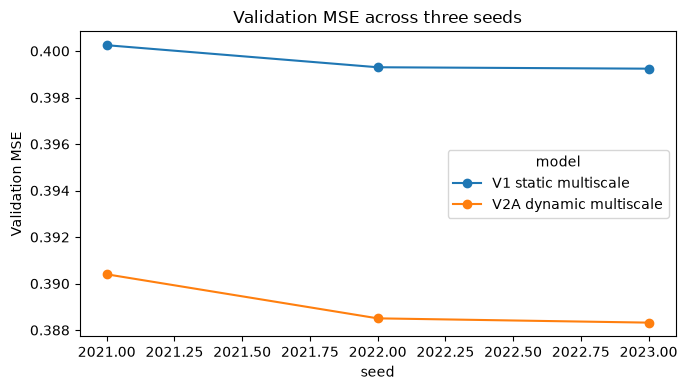

In [3]:
axis = validation.pivot(index="seed", columns="model", values="val_mse").plot(
    marker="o", figsize=(7, 4), ylabel="Validation MSE"
)
axis.set_title("Validation MSE across three seeds")
axis.figure.tight_layout()
axis.figure.savefig(FIGURE_ROOT / "validation_mse_by_seed.png", dpi=200)
plt.show()

## 3. Test comparison figure

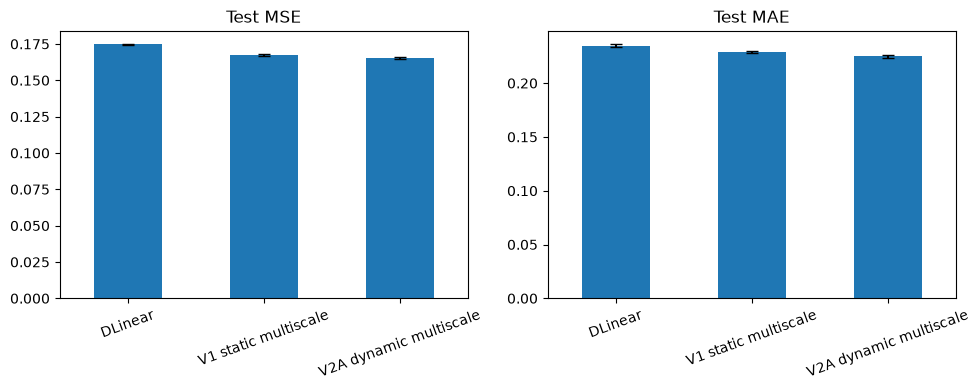

In [4]:
plot_data = test_summary.set_index("model")
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_data["test_mse_mean"].plot(
    kind="bar", yerr=plot_data["test_mse_std"], capsize=4, ax=axes[0]
)
plot_data["test_mae_mean"].plot(
    kind="bar", yerr=plot_data["test_mae_std"], capsize=4, ax=axes[1]
)
axes[0].set_title("Test MSE")
axes[1].set_title("Test MAE")
for axis in axes:
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=20)
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "test_metrics.png", dpi=200)
plt.show()

The saved figures are optional report assets. The numerical CSV files under
`results/` remain the source of truth.